In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import Levenshtein
from tqdm import tqdm
import random

In [6]:
def plot_anchor_stats(json_path, n_top=5):
    """
    输入:
        json_path: 导出的 anchor_index.json 文件路径
        n_top: 分析 query 到第 n 近 anchor 的距离分布
        sample_anchor_pairs: anchor-anchor pair 随机抽样数量
    """
    with open(json_path) as f:
        data = json.load(f)
    
    anchors = sorted(set([a["seq"] for a in data["anchors"]]))
    queries = data["queries"]

    print(f"Loaded {len(anchors)} anchors and {len(queries)} queries")

    # --------------------------
    # 1️⃣ 最近 anchor 距离分布
    # --------------------------
    nearest_dists = []
    for q in tqdm(queries, desc="Computing nearest anchor distance"):
        d = min(Levenshtein.distance(q, a) for a in anchors)
        nearest_dists.append(d)
    
    plt.hist(nearest_dists)
    plt.title("Distribution of nearest anchor distances")
    plt.xlabel("Edit distance to nearest anchor")
    plt.ylabel("Query count")
    plt.tight_layout()
    plt.show()

    # --------------------------
    # 2️⃣ 前 n 个 anchor 的距离分布（小提琴图 + 散点 + 平均值）
    # --------------------------
    topn_results = []
    for q in tqdm(queries, desc="Computing top-n anchor distances"):
        dists = sorted(Levenshtein.distance(q, a) for a in anchors)
        topn_results.append(dists[:n_top])

    df_topn = pd.DataFrame(topn_results, columns=[f"top{i+1}" for i in range(n_top)])
    
    fig, ax = plt.subplots(figsize=(10, 5))

    parts = ax.violinplot(
        [df_topn[c] for c in df_topn.columns],
        showmeans=False,
        showextrema=False,
        showmedians=False
    )

    # 设置小提琴样式
    for pc in parts['bodies']:
        pc.set_facecolor("#7ab8ff")
        pc.set_edgecolor("black")
        pc.set_alpha(0.6)

    # 添加散点（加抖动以避免重叠）
    for i, col in enumerate(df_topn.columns):
        x = np.random.normal(i + 1, 0.05, size=len(df_topn[col]))
        ax.scatter(x, df_topn[col], alpha=0.3, s=12, color="tab:blue", edgecolor="none")

    # 画平均值折线
    means = df_topn.mean(axis=0)
    ax.plot(range(1, n_top + 1), means, marker="o", color="pink", linewidth=2, label="Mean")

    ax.set_xticks(range(1, n_top + 1))
    ax.set_xticklabels(df_topn.columns)
    ax.set_title(f"Distribution of distances to top-{n_top} anchors")
    ax.set_xlabel("n-th closest anchor")
    ax.set_ylabel("Edit distance")
    ax.legend()
    plt.tight_layout()
    plt.show()

    # --------------------------
    # 3️⃣ anchor-anchor 距离分布
    # --------------------------
    anchor_pairs = [(i, j) for i in range(len(anchors)) for j in range(i+1, len(anchors))]#random.sample(
    #     ,
    #     len(anchors) * (len(anchors) - 1)
    # )
    dists = [Levenshtein.distance(anchors[i], anchors[j]) for i, j in tqdm(anchor_pairs, desc="Anchor-anchor distances")]
    dists_close = [dist for dist in dists if dist <= 10]

    plt.hist(dists, bins=30, alpha=0.7, edgecolor="black")
    plt.title(f"Anchor-anchor distance distribution")
    plt.xlabel("Edit distance")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    plt.hist(dists_close, bins=30, alpha=0.7, edgecolor="black", log=True)
    plt.title(f"Anchor-anchor distance distribution (close range)")
    plt.xlabel("Edit distance")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

Loaded 1000 anchors and 1000 queries


Computing nearest anchor distance: 100%|██████████| 1000/1000 [00:00<00:00, 2142.58it/s]


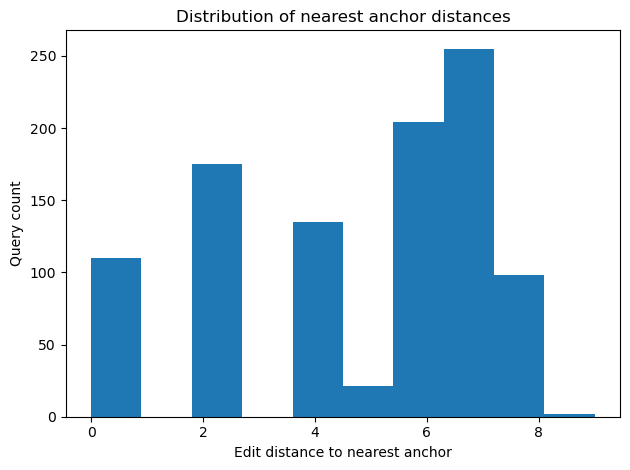

Computing top-n anchor distances: 100%|██████████| 1000/1000 [00:00<00:00, 1415.52it/s]


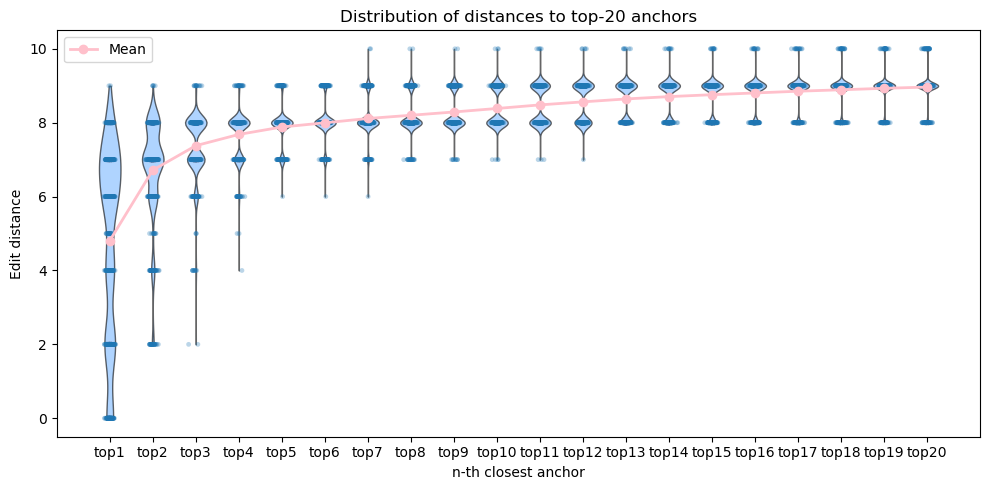

Anchor-anchor distances: 100%|██████████| 499500/499500 [00:00<00:00, 1649355.98it/s]


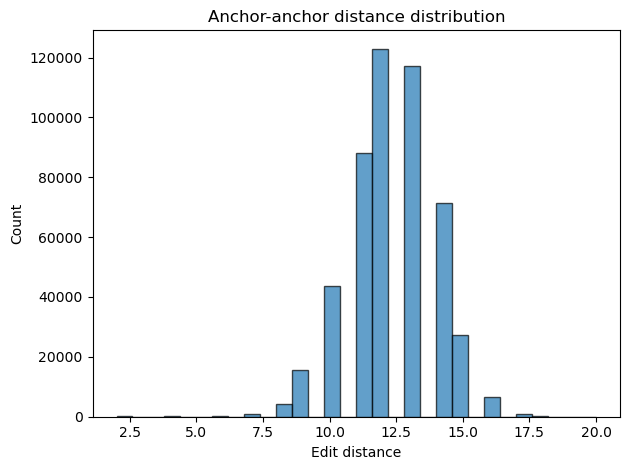

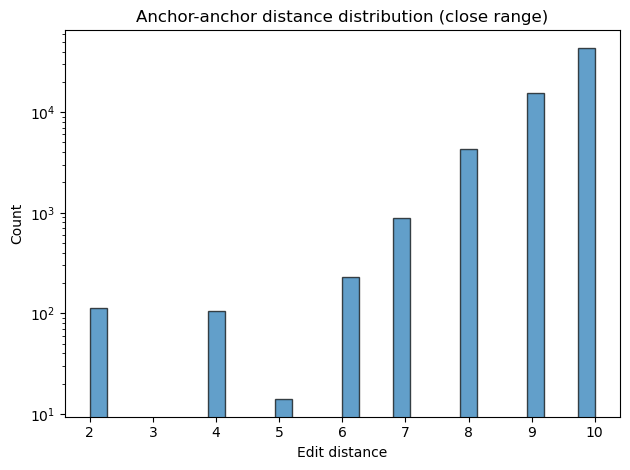

In [7]:
plot_anchor_stats("../anchor_index.json", n_top=20)